In [21]:
import pandas as pd
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interface
import ipywidgets as widgets
from IPython.display import display, clear_output

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Model + evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df=pd.read_csv("clean_data.csv")

In [6]:
df.isnull().sum().mean()*100

np.float64(0.0)

# Survival Graph

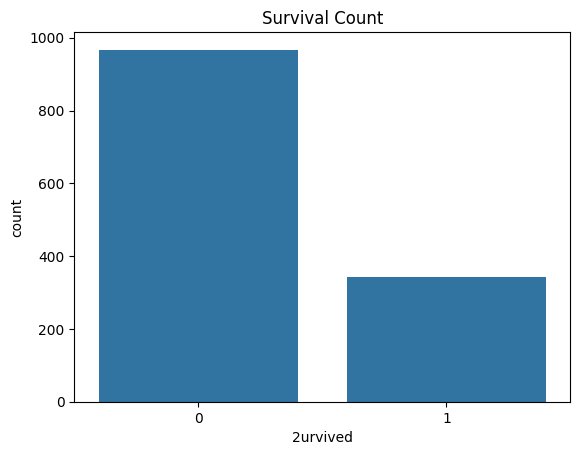

In [11]:
sns.countplot(x='2urvived', data=df)
plt.title("Survival Count")
plt.show()

# Survival By Gender

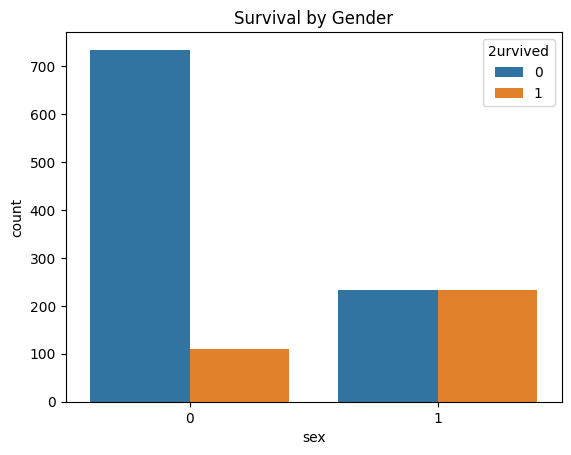

In [13]:
sns.countplot(x='sex', hue='2urvived', data=df)
plt.title("Survival by Gender")
plt.show()

# Age Distribution

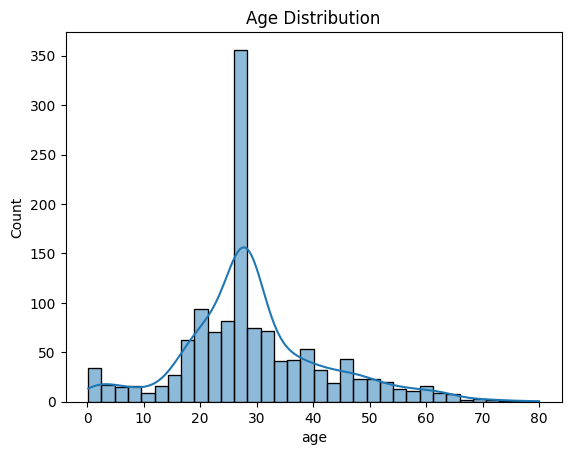

In [14]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Encoding Convert Categorical to Numeric

In [15]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])  
# male = 1, female = 0 (or vice versa)

In [16]:
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['2urvived']

# TRAIN TEST SPLIT

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Choose Model (1) LOGISTIC REGRESSION

In [18]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7862595419847328


# MODEL 02 (Random Forest)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7862595419847328


In [34]:
sex_options = list(le.classes_)

pclass_widget = widgets.Dropdown(
    options=[1, 2, 3],
    value=3,
    description="Pclass:",
)
sex_widget = widgets.Dropdown(
    options=sex_options,
    value=sex_options[0],
    description="Sex:",
)
age_widget = widgets.IntSlider(
    value=int(df["age"].median()),
    min=0,
    max=80,
    step=1,
    description="Age:",
    continuous_update=False,
)
fare_widget = widgets.FloatSlider(
    value=float(df["fare"].median()),
    min=0,
    max=float(df["fare"].max()),
    step=0.5,
    description="Fare:",
    continuous_update=False,
)
predict_button = widgets.Button(description="Predict survival", button_style="primary")
output = widgets.Output()


def predict_survival(button=None):
    if 'rf_model' not in globals():
        with output:
            clear_output(wait=True)
            print("Run the Random Forest training cell first.")
        return

    sample = pd.DataFrame(
        {
            "pclass": [pclass_widget.value],
            "sex": [le.transform([sex_widget.value])[0]],
            "age": [age_widget.value],
            "fare": [fare_widget.value],
        }
    )
    prediction = int(rf_model.predict(sample)[0])
    probability = float(rf_model.predict_proba(sample)[0][1])

    with output:
        clear_output(wait=True)
        print("Predicted survival:", "Yes" if prediction == 1 else "No")
        print(f"Survival probability: {probability:.2%}")


predict_button.on_click(predict_survival)
display(widgets.VBox([pclass_widget, sex_widget, age_widget, fare_widget, predict_button, output]))

In [10]:
df.columns

Index(['passengerid', 'age', 'fare', 'sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'pclass', 'zero.15', 'zero.16', 'embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='str')